# Univariate Linear Regression: Weight vs MPG

**Step 1**: Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**Step 2**: Load the dataset

In [2]:
#Read the csv file
df=pd.read_csv("auto-mpg.csv")

In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


**Step 3**: Select the feature (X = weight) and the target (y = mpg)

In [4]:
X = df[['weight']]
y = df['mpg']

In [5]:
print(X.shape)
print(y.shape)

(398, 1)
(398,)


**Step 4**: Train test split (80% train, 20% test)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(318, 1)
(80, 1)
(318,)
(80,)


**Step 5**: Create and train the model

In [8]:
model = LinearRegression()

In [9]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Step 6**: Coefficient and intercept

In [10]:
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

Coefficient: -0.0078052423515948795
Intercept: 46.78206336645047


**Step 7**: Predict on the test set

In [11]:
y_pred = model.predict(X_test)

In [12]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print(comparison.head(10))

   Actual  Predicted
0    33.0  32.771653
1    28.0  26.293302
2    19.0  26.223055
3    13.0  16.029409
4    14.0  13.711252
5    27.0  30.391054
6    24.0  24.420044
7    13.0   9.824241
8    17.0  15.092779
9    21.0  24.341992


**Step 8**: Regression equation

In [13]:
print("Regression Equation:")
print(f"mpg = {model.intercept_:.2f} + ({model.coef_[0]:.5f} × weight)")

Regression Equation:
mpg = 46.78 + (-0.00781 × weight)


**Step 9**: Evaluation metrics (MAE, MSE, RMSE, R²)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 3.1177861992064573
MSE: 14.894861064636194
RMSE: 3.8593860994510765
R² Score: 0.722971057303075


**Step 10**: Residuals (actual − predicted)

In [15]:
residuals = y_test - y_pred
print(residuals.head())

198    0.228347
396    1.706698
33    -7.223055
208   -3.029409
93     0.288748
Name: mpg, dtype: float64


**Step 11**: Visualization

**Plot 1**: Regression line on the test data

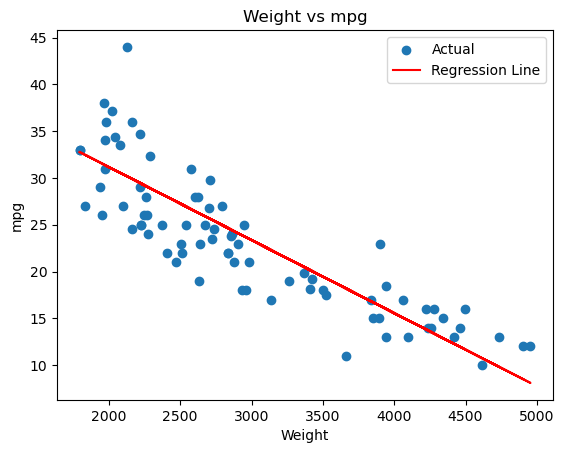

In [16]:
plt.scatter(X_test, y_test, label="Actual")
plt.plot(X_test, y_pred, color="red", label="Regression Line")
plt.xlabel("Weight")
plt.ylabel("mpg")
plt.title("Weight vs mpg")
plt.legend()
plt.show()

**Plot 2**: Residuals vs predictions

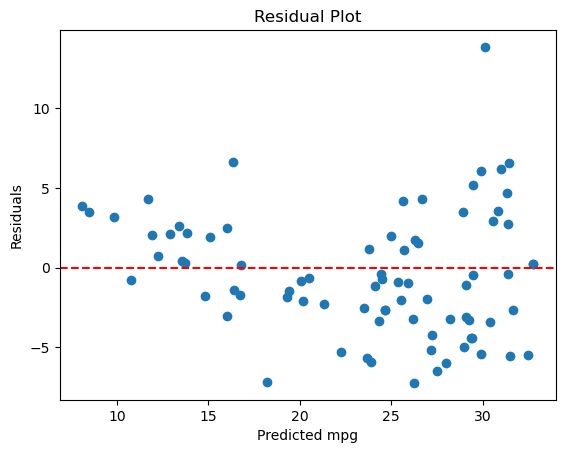

In [17]:
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted mpg")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

**Plot 3**: Distribution of residuals

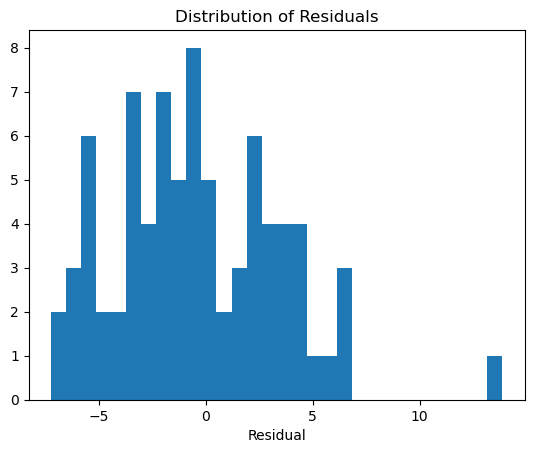

In [18]:
plt.hist(residuals, bins=30)
plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.show()